In [1]:
from Tools_U1_plaquette import *

### This notebook reproduces the plots obtained in "MISSION-Mathieu_basis_sparse.ipynb", where we obtain the expectation values of the plaquette operator and the electric field fluctuations for N=13 for several $\lambda/g$ and $\lambda/m$

In [2]:
N = 13
npoints = 30

filename_main = f"plaquette_reduced4vars_alphas0_expvals_data_meshgrids_N_{N}_npoints_{npoints}_mathieu_basis_sparse.npz"
data_main = np.load(filename_main)
λs_over_gs = data_main["lambda_over_gs"]
λs_over_ms = data_main["lambda_over_ms"]
results_plaquette_operator = data_main["expvals_plaquette_operator"]
results_n12 = data_main["expvals_n12"]
results_n12_sqr = data_main["expvals_n12_sqr"]     
results_variance_n12 = data_main["expvals_variance_n12"]
results_n24 = data_main["expvals_n24"]
results_n24_sqr = data_main["expvals_n24_sqr"]     
results_variance_n24 = data_main["expvals_variance_n24"]
results_n13 = data_main["expvals_n13"]
results_n13_sqr = data_main["expvals_n13_sqr"]     
results_variance_n13 = data_main["expvals_variance_n13"]
results_n34 = data_main["expvals_n34"]
results_n34_sqr = data_main["expvals_n34_sqr"]     
results_variance_n34 = data_main["expvals_variance_n34"]

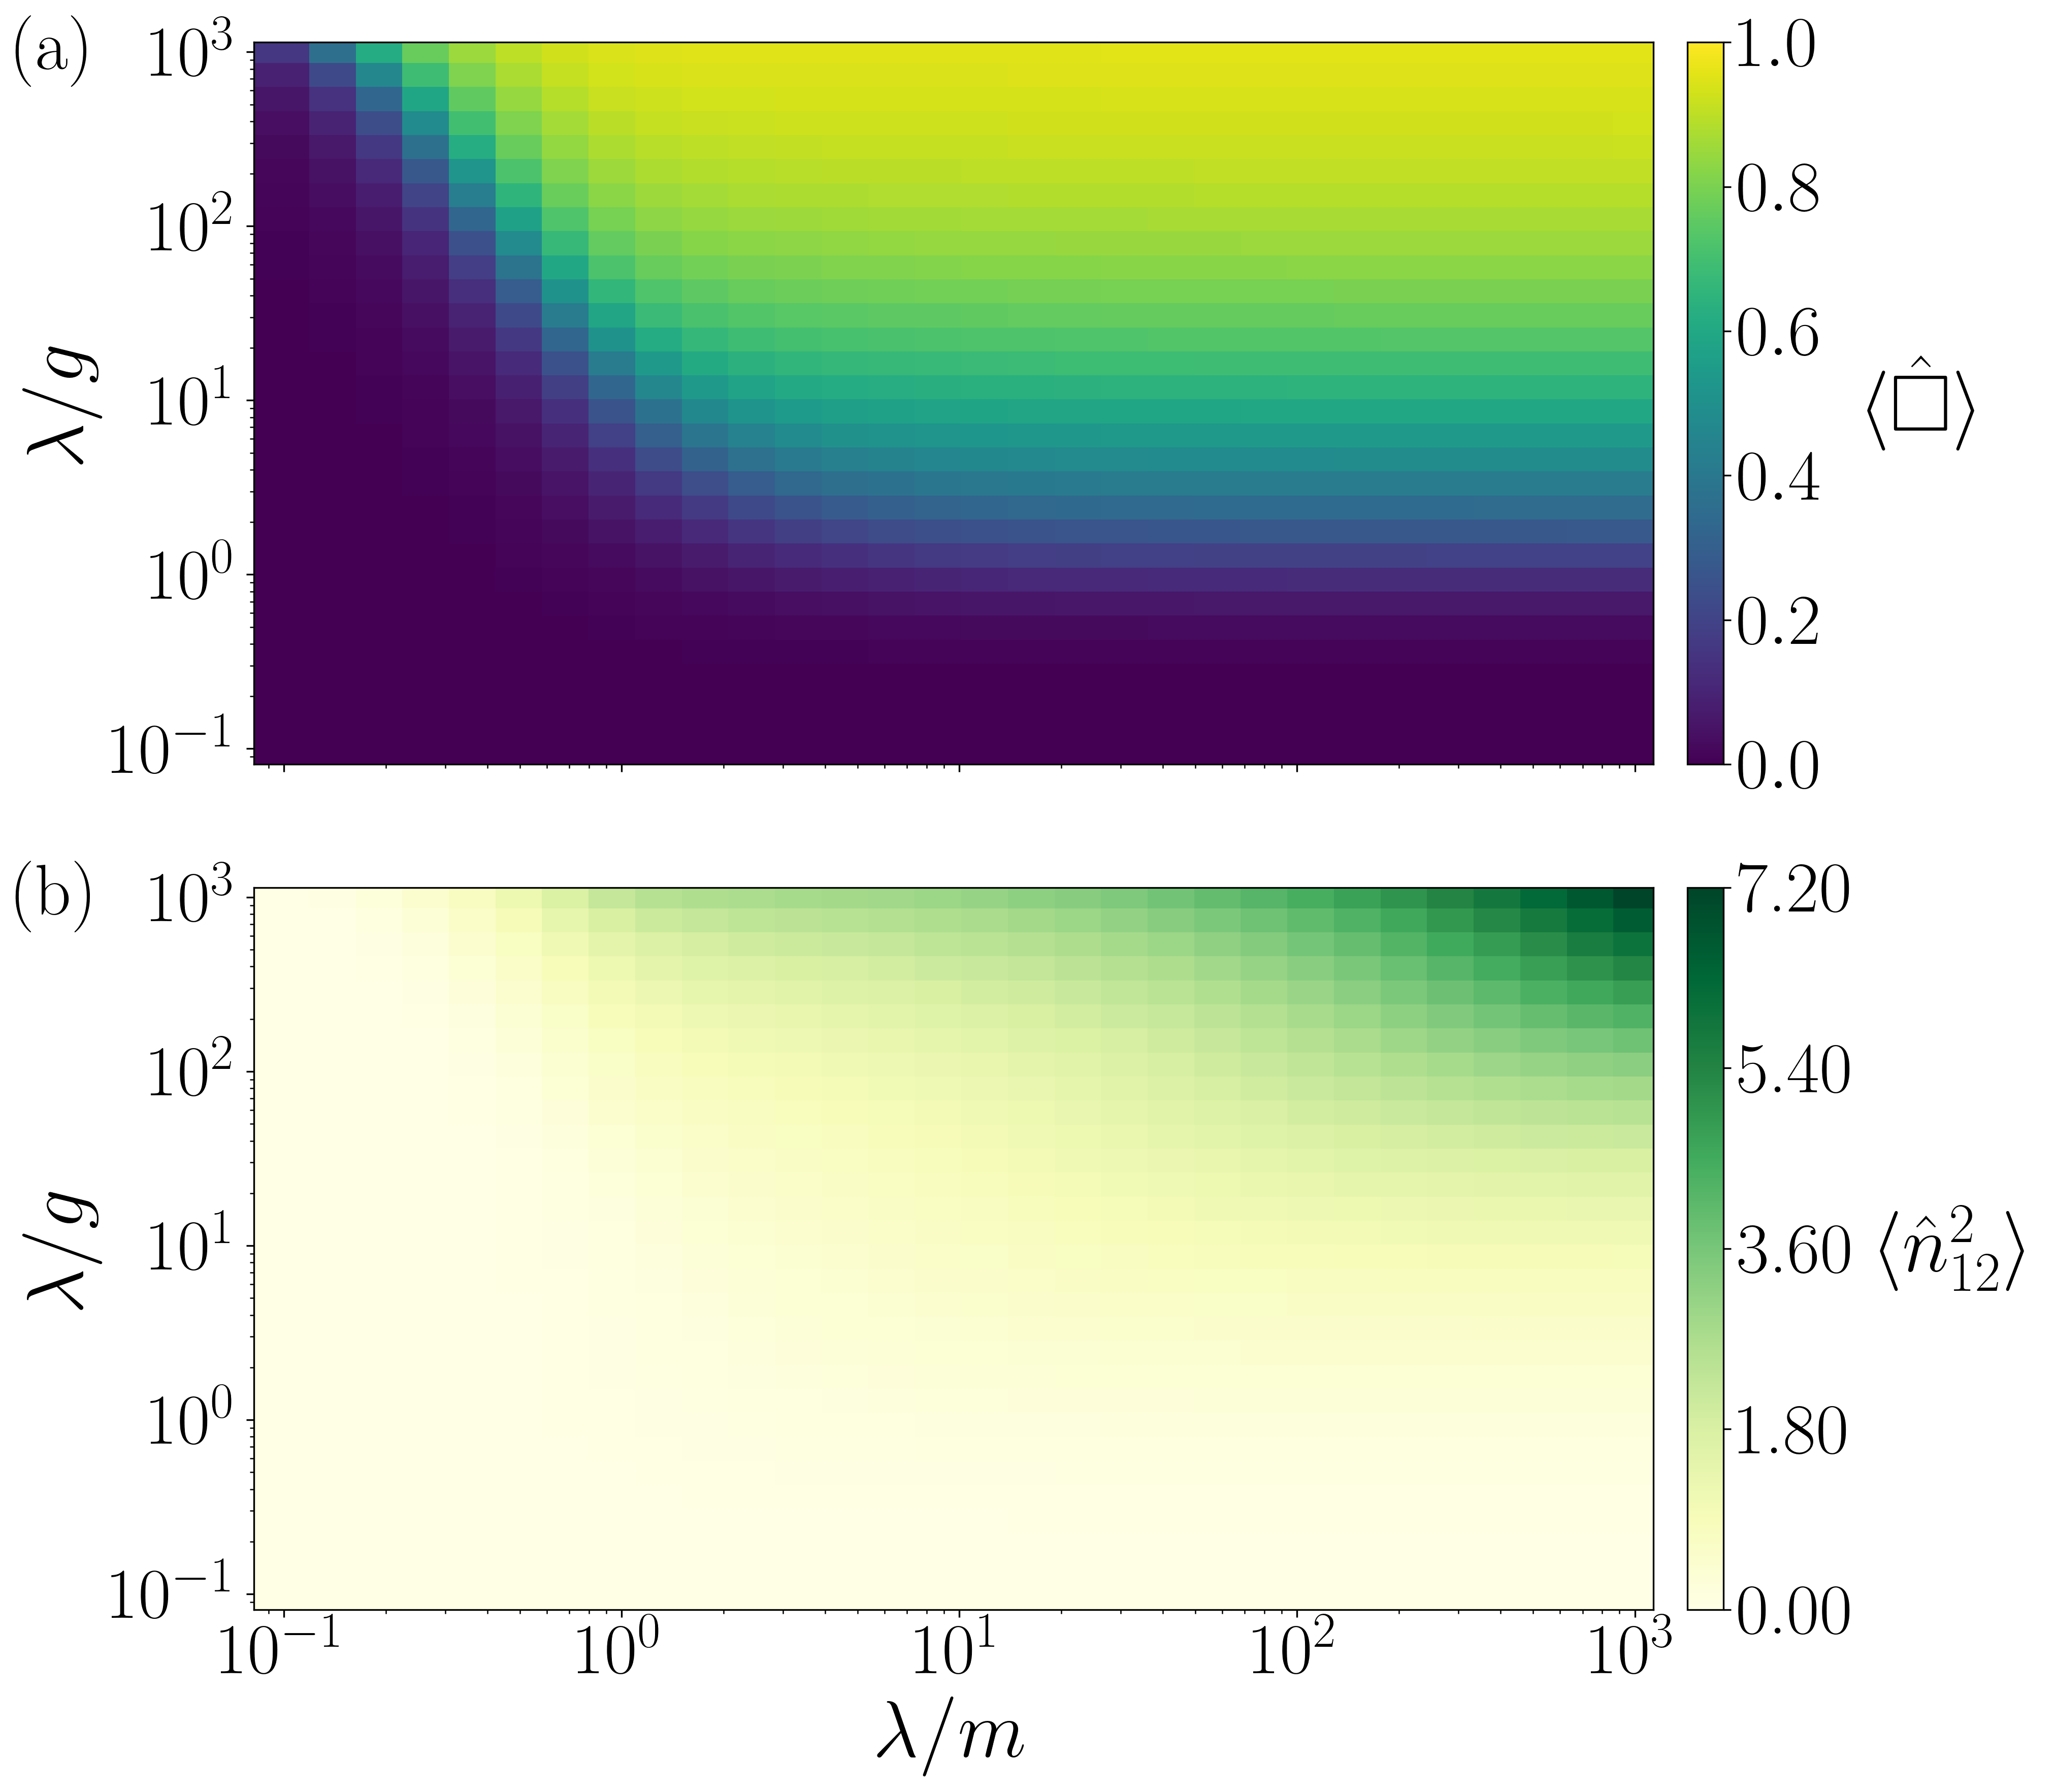

In [ ]:
plt.rcParams.update({
    #"figure.figsize": (8, 5),
    "figure.dpi": 100,
    "font.size": 24,#14,
    "font.family": "serif",
    "text.usetex": True,
    "axes.labelsize": 38,#16,
    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "axes.titlesize": 14,
    "axes.grid": False,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.fontsize": 14,#14,
    "legend.title_fontsize": 16,
    "legend.frameon": False,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})

fig, axes = plt.subplots(2, 1, figsize=(14, 12.3), sharex=True, dpi=300)

# ----- Left plot: plaquette operator -----
X, Y = np.meshgrid(λs_over_ms, λs_over_gs)
c = axes[0].pcolormesh(
X, Y, results_plaquette_operator,
shading='auto', cmap='viridis',
norm=plt.Normalize(vmin=0, vmax=1)
)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylabel(r'$\lambda / g$')
axes[0].text(0.016, 800, r"$(\rm a)$", fontsize=34)
cbar = fig.colorbar(c, ax=axes[0], pad=0.02)
cbar.set_label(
    r'$\langle \hat{\square} \rangle$',
    rotation=0,
    labelpad=50,
    va='center'
)

# ----- Right plot: variance n12 -----
X, Y = np.meshgrid(λs_over_ms, λs_over_gs)
c00 = axes[1].pcolormesh(
X, Y, results_variance_n12,
shading='auto', cmap='YlGn',
norm=plt.Normalize(vmin=np.min(results_variance_n12), vmax=np.max(results_variance_n12))
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$\lambda / m$')
axes[1].set_ylabel(r'$\lambda / g$')
axes[1].text(0.016, 800, r"$(\rm b)$", fontsize=34)
vmin,vmax = c00.get_clim()
ticks = np.linspace(vmin,vmax,5)
cbar00 = fig.colorbar(c00, ax=axes[1], pad=0.02, ticks = ticks)
cbar00.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar00.set_label(
    r'$\langle \hat{n}^2_{12} \rangle$',
    rotation=0,
    labelpad=50,
    va='center'
)

plt.tight_layout()
fig.savefig(
    f"LGT_SCQs_plaquette_reduced_def_OCT25/"
    f"LGT_SCQs_plaquette_reduced4vars_alphas0_observable_N_{int(N)}_npoints_{npoints}_meshgrid_gs_plaquetteop_and_variance_n12_operator_mathieu_basis_sparse_vertical.pdf", 
    dpi = 600
)
plt.show()